In [38]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn import datasets
from sklearn.model_selection import GridSearchCV
import pandas as pd 
import numpy as np
import shap
import matplotlib.pyplot as plt

In [39]:
df = pd.read_excel('Working Version - default of credit card clients.xls',header=1)
df = pd.DataFrame(df)
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT5,PAY_AMT6,default payment next month,UTIL_t1,UTIL_t2,UTIL_t3,UTIL_t4,UTIL_t5,UTIL_t6,Average of Util Over 6 Months
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,1,0.195650,0.155100,0.034450,0.000000,0.000000,0.000000,0.064200
1,2,120000,2,2,2,26,-1,2,0,0,...,0,2000,1,0.022350,0.014375,0.022350,0.027267,0.028792,0.027175,0.023718
2,3,90000,2,2,2,34,0,0,0,0,...,1000,5000,0,0.324878,0.155856,0.150656,0.159233,0.166089,0.172767,0.188246
3,4,50000,2,2,1,37,0,0,0,0,...,1069,1000,0,0.939800,0.964660,0.985820,0.566280,0.579180,0.590940,0.771113
4,5,50000,1,2,1,57,-1,0,-1,0,...,689,679,0,0.172340,0.113400,0.716700,0.418800,0.382920,0.382620,0.364463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,5000,1000,0,0.858855,0.876432,0.947114,0.400018,0.141986,0.072636,0.549507
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,0,0,0,0.011220,0.012187,0.023347,0.059860,0.034600,0.000000,0.023536
29997,29998,30000,1,2,2,37,4,3,2,-1,...,2000,3100,1,0.118833,0.111867,0.091933,0.695933,0.686067,0.645233,0.391644
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52964,1804,1,-0.020563,0.979738,0.953800,0.659675,0.148187,0.611800,0.555440


In [40]:
X = df.loc[:,df.columns != 'default payment next month'].copy()
X = pd.DataFrame(X)
Y = df.loc[:,'default payment next month'].values.copy()


#To be one hot encoded
XC = X.loc[:,['SEX','EDUCATION','MARRIAGE','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].values
XC

#To be scaled normallly -> N(0,1)
X = X.loc[:, ~X.columns.isin(['SEX','EDUCATION','MARRIAGE','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6', 
'Average of Util Over 6 Months', 
'ID'])].values

#Scaling for variables
scaler = StandardScaler()
cate = OneHotEncoder()
X = scaler.fit_transform(X)
XC = cate.fit_transform(XC)

XC = XC.toarray()
X_combined = np.hstack([X, XC])



In [41]:

x_trainv, x_test, y_trainv, y_test = train_test_split(X_combined, Y, test_size=0.1,stratify=Y, random_state = 28)

x_train, x_v, y_train, y_v = train_test_split(x_trainv, y_trainv, test_size=0.222, stratify=y_trainv, random_state = 28)

x_v = torch.tensor(x_v,dtype=torch.float32)
y_v = torch.tensor(y_v,dtype=torch.float32).view(-1, 1)

x_train = torch.tensor(x_train,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.float32).view(-1, 1)

x_test = torch.tensor(x_test,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32).view(-1, 1)


In [42]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(97, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = Net()

pos_weight = torch.tensor([3.0])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

model.net[-1] = nn.Identity()

optimizer = optim.AdamW(model.parameters(), lr=1e-3)

In [43]:
epochs = 50
patience = 10
best_val_loss = float('inf')
counter = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()


    model.eval()
    with torch.no_grad():
        val_outputs = model(x_v)
        val_loss = criterion(val_outputs, y_v)

    print(f"Epoch {epoch+1}: Train Loss={loss.item():.4f}, Val Loss={val_loss.item():.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model_state = model.state_dict()
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_model_state)

Epoch 1: Train Loss=1.0210, Val Loss=0.9943
Epoch 2: Train Loss=0.9911, Val Loss=0.9894
Epoch 3: Train Loss=0.9717, Val Loss=0.9840
Epoch 4: Train Loss=0.9484, Val Loss=0.9782
Epoch 5: Train Loss=0.9322, Val Loss=0.9719


Epoch 6: Train Loss=0.9209, Val Loss=0.9652
Epoch 7: Train Loss=0.9051, Val Loss=0.9581
Epoch 8: Train Loss=0.8969, Val Loss=0.9506
Epoch 9: Train Loss=0.8868, Val Loss=0.9427
Epoch 10: Train Loss=0.8796, Val Loss=0.9346
Epoch 11: Train Loss=0.8708, Val Loss=0.9262
Epoch 12: Train Loss=0.8631, Val Loss=0.9177
Epoch 13: Train Loss=0.8568, Val Loss=0.9092
Epoch 14: Train Loss=0.8550, Val Loss=0.9008
Epoch 15: Train Loss=0.8505, Val Loss=0.8927
Epoch 16: Train Loss=0.8434, Val Loss=0.8849
Epoch 17: Train Loss=0.8425, Val Loss=0.8774
Epoch 18: Train Loss=0.8391, Val Loss=0.8703
Epoch 19: Train Loss=0.8356, Val Loss=0.8636
Epoch 20: Train Loss=0.8353, Val Loss=0.8575
Epoch 21: Train Loss=0.8309, Val Loss=0.8519
Epoch 22: Train Loss=0.8289, Val Loss=0.8469
Epoch 23: Train Loss=0.8292, Val Loss=0.8425
Epoch 24: Train Loss=0.8270, Val Loss=0.8387
Epoch 25: Train Loss=0.8250, Val Loss=0.8354
Epoch 26: Train Loss=0.8229, Val Loss=0.8325
Epoch 27: Train Loss=0.8217, Val Loss=0.8300
Epoch 28: Trai

<All keys matched successfully>

In [44]:
model.eval()
with torch.no_grad():
    # ----- VALIDATION -----
    val_outputs = model(x_v)
    val_probs = torch.sigmoid(val_outputs).cpu().numpy()
    y_predval = (val_probs > 0.5).astype(int)
    y_v_np = y_v.cpu().numpy()


    print("----- VALIDATION METRICS -----")
    print(f"Accuracy : {accuracy_score(y_v_np, y_predval):.4f}")
    print(f"Precision: {precision_score(y_v_np, y_predval):.4f}")
    print(f"Recall   : {recall_score(y_v_np, y_predval):.4f}")
    print(f"F1 Score : {f1_score(y_v_np, y_predval):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_v_np, val_probs):.4f}")

    # ----- TEST -----
    test_outputs = model(x_test)
    test_probs = torch.sigmoid(test_outputs).cpu().numpy()
    y_predtest = (test_probs > 0.5).astype(int)
    y_test_np = y_test.cpu().numpy()

    print("\n----- TEST METRICS -----")
    print(f"Accuracy : {accuracy_score(y_test_np, y_predtest):.4f}")
    print(f"Precision: {precision_score(y_test_np, y_predtest):.4f}")
    print(f"Recall   : {recall_score(y_test_np, y_predtest):.4f}")
    print(f"F1 Score : {f1_score(y_test_np, y_predtest):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_test_np, test_probs):.4f}")



----- VALIDATION METRICS -----
Accuracy : 0.7658
Precision: 0.4772
Recall   : 0.6146
F1 Score : 0.5372
ROC AUC  : 0.7789

----- TEST METRICS -----
Accuracy : 0.7753
Precision: 0.4941
Recall   : 0.6310
F1 Score : 0.5542
ROC AUC  : 0.7922


SHAP values shape: (100, 97)
X_test shape     : (100, 97)


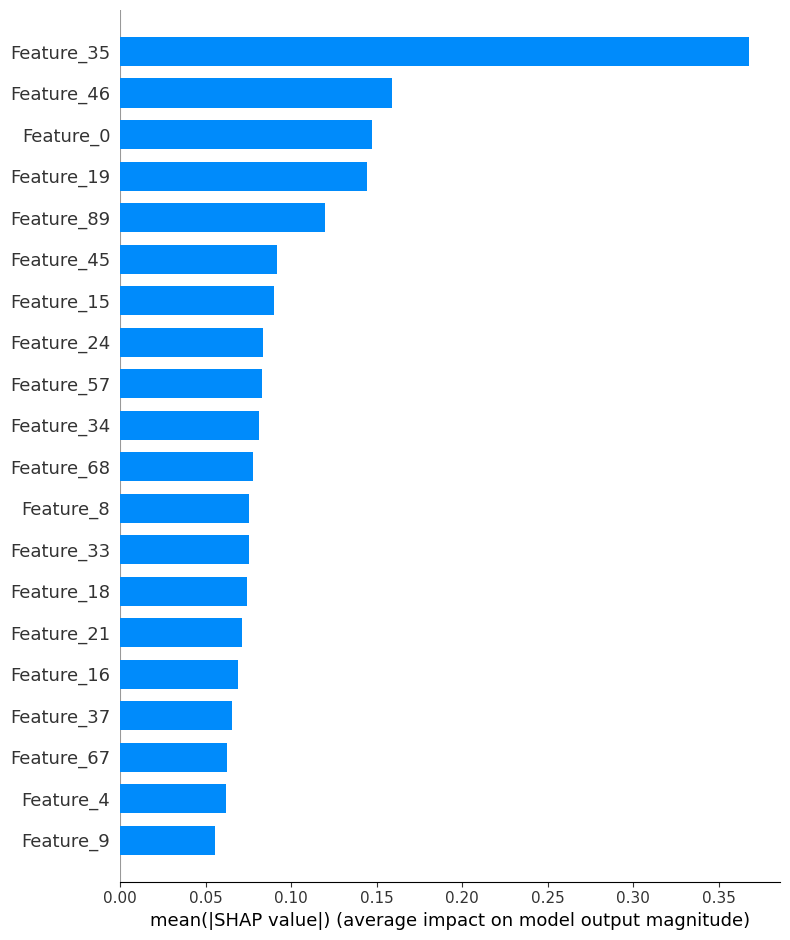

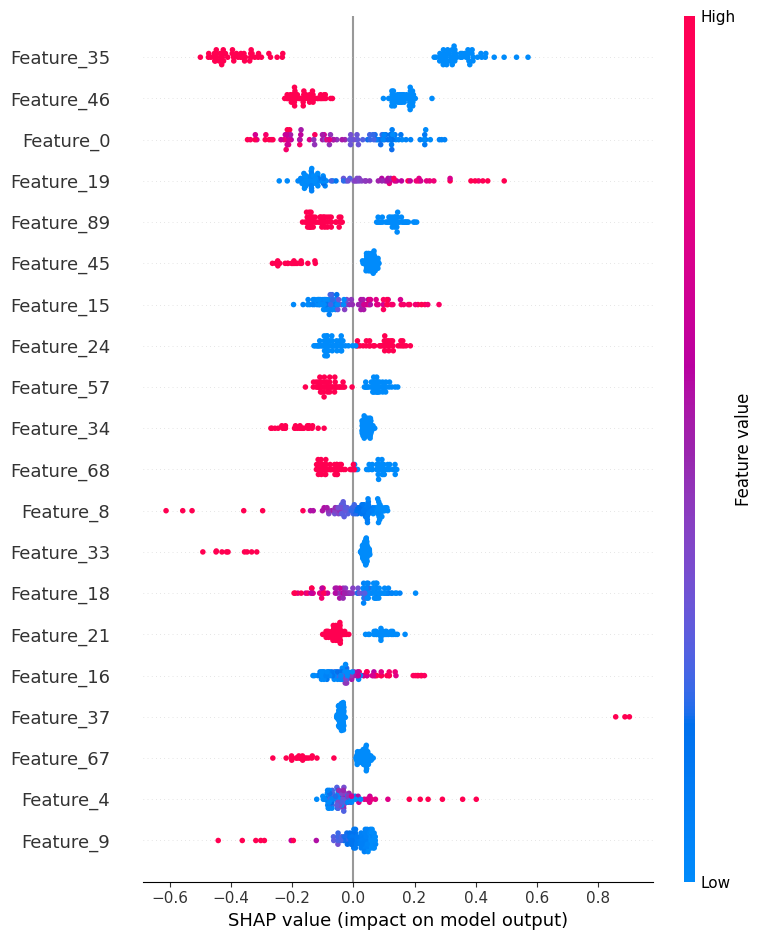

In [45]:
# Fixed SHAP for MLP - handles shape issues
model.eval()

# x_train and x_test are already tensors in this notebook
X_train_sample = x_train[:200]
X_test_sample = x_test[:100]

# DeepExplainer works with PyTorch models
explainer = shap.DeepExplainer(model, X_train_sample)
shap_values = explainer.shap_values(X_test_sample)

# DeepExplainer returns shape (100, 97, 1) for single output MLP
# Squeeze the last dimension to get (100, 97)
shap_vals_np = shap_values[:, :, 0]
X_test_np = X_test_sample.detach().numpy()

print(f"SHAP values shape: {shap_vals_np.shape}")
print(f"X_test shape     : {X_test_np.shape}")

# Feature names
feature_names = [f"Feature_{i}" for i in range(X_test_np.shape[1])]

# Global bar plot - mean absolute SHAP value per feature
shap.summary_plot(shap_vals_np, X_test_np,
                  feature_names=feature_names,
                  plot_type="bar",
                  max_display=20,
                  show=True)

# Beeswarm plot - direction and distribution of SHAP values
shap.summary_plot(shap_vals_np, X_test_np,
                  feature_names=feature_names,
                  max_display=20,
                  show=True)



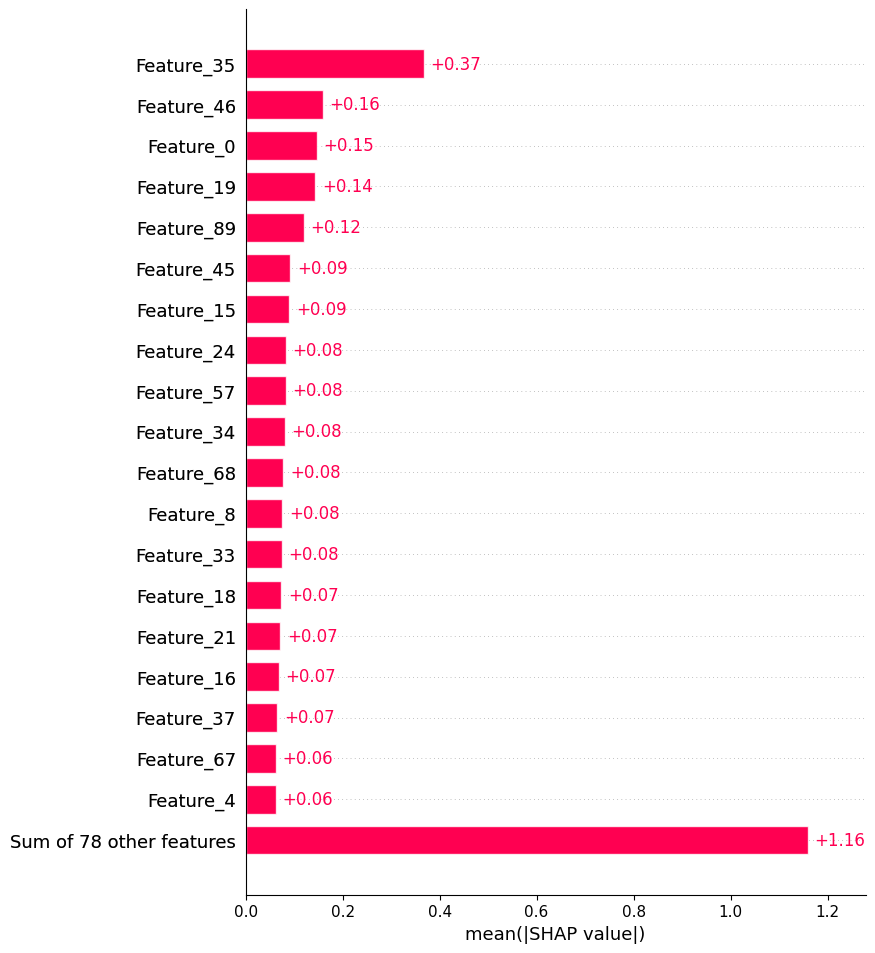

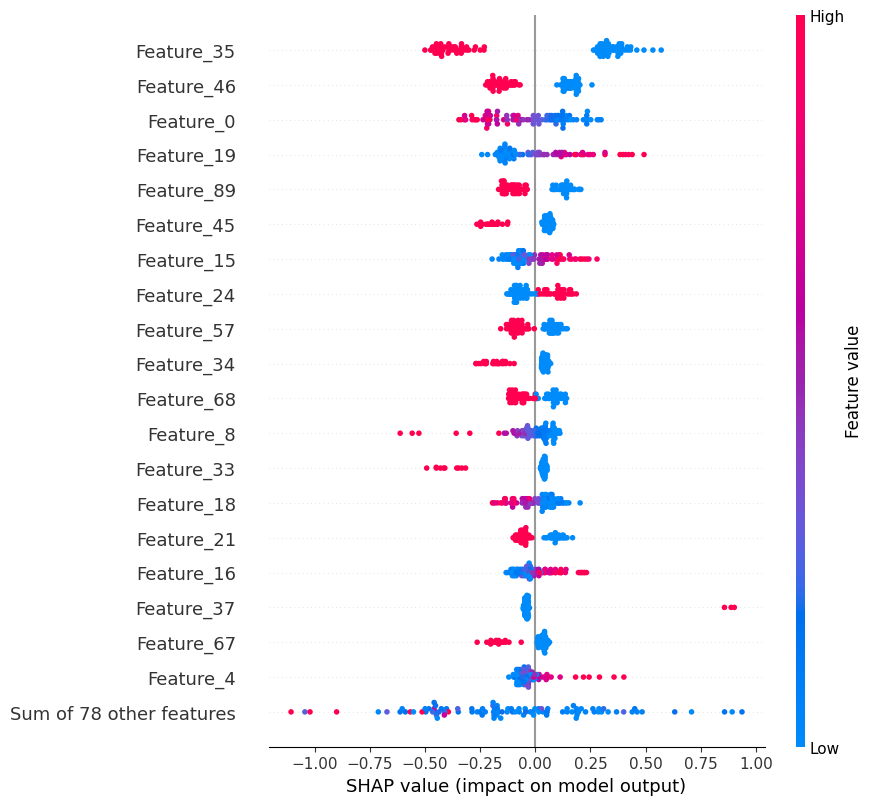

In [46]:
# Rename features for readable SHAP plot

# feature_name_map = {
#     'X1': 'LIMIT_BAL',
#     'X2': 'SEX',
#     'X3': 'EDUCATION',
#     'X4': 'MARRIAGE',
#     'X5': 'AGE',
#     'X6': 'PAY_0',
#     'X7': 'PAY_2',
#     'X8': 'PAY_3',
#     'X9': 'PAY_4',
#     'X10': 'PAY_5',
#     'X11': 'PAY_6',
#     'X12': 'BILL_AMT1',
#     'X13': 'BILL_AMT2',
#     'X14': 'BILL_AMT3',
#     'X15': 'BILL_AMT4',
#     'X16': 'BILL_AMT5',
#     'X17': 'BILL_AMT6',
#     'X18': 'PAY_AMT1',
#     'X19': 'PAY_AMT2',
#     'X20': 'PAY_AMT3',
#     'X21': 'PAY_AMT4',
#     'X22': 'PAY_AMT5',
#     'X23': 'PAY_AMT6'
# }

# MLP has 97 features after one-hot encoding
# Generate feature names for all 97 columns
#feature_names_mlp = mlp_feature_names

# Rebuild explanation using MLP variable names
shap_explanation_named = shap.Explanation(
    values=shap_vals_np,
    base_values=np.zeros(shap_vals_np.shape[0]),
    data=X_test_np,
    feature_names=feature_names
)

# Replot with names
shap.plots.bar(shap_explanation_named,
               max_display=20,
               show=True)

shap.plots.beeswarm(shap_explanation_named,
                    max_display=20,
                    show=True)

In [47]:
feature_names = [f"Feature_{i}" for i in range(x_train.shape[1])]

bill_cols = ['Feature_12','Feature_13','Feature_14','Feature_15','Feature_16','Feature_17']
util_col_names = ['Feature_6','Feature_7','Feature_8','Feature_9','Feature_10','Feature_11']
limit_idx = feature_names.index('Feature_0')  # assuming X1 is Feature_0
util_avg_idx = x_train.shape[1] - 1  # last column, adjust if needed

bill_idx = [feature_names.index(c) for c in bill_cols]
util_idx = [feature_names.index(c) for c in util_col_names]

# %%
# PyTorch version of run_intervention
def run_intervention(model, X_original, intervention_fn, label):
    """
    intervention_fn: a function that takes X (tensor) and returns modified X (tensor)
    """
    model.eval()
    with torch.no_grad():
        X_modified = intervention_fn(X_original.clone())
        # Get predicted probabilities
        prob_original = torch.sigmoid(model(X_original)).cpu().numpy().flatten()
        prob_modified = torch.sigmoid(model(X_modified)).cpu().numpy().flatten()
        
    delta_p = prob_modified - prob_original  # negative = reduction
    
    print(f"\n--- {label} ---")
    print(f"Mean ΔP(default)       : {delta_p.mean():.6f}")
    print(f"Mean |ΔP(default)|     : {np.abs(delta_p).mean():.6f}")
    print(f"Clients with reduction : {(delta_p < 0).sum()} / {len(delta_p)}")
    
    return delta_p




In [48]:
results_A = {}

for pct in [0.10, 0.25, 0.50]:
    def intervention_A(X, reduction=pct):
        X_mod = X.clone()
        
        # Reduce bill amounts
        X_mod[:, bill_idx] = X_mod[:, bill_idx] * (1 - reduction)
        
        # Avoid division by zero
        limit = X_mod[:, limit_idx].unsqueeze(1)
        limit_safe = torch.where(limit == 0, torch.nan, limit)
        
        # Recompute utilization ratios
        X_mod[:, util_idx] = X_mod[:, bill_idx] / limit_safe
        
        # Compute UTIL_avg
        X_mod[:, util_avg_idx] = torch.nanmean(X_mod[:, util_idx], dim=1)
        
        # Clip to training min/max
        for col in bill_idx + util_idx + [util_avg_idx]:
            X_mod[:, col] = torch.clamp(
                X_mod[:, col],
                min=x_train[:, col].min(),
                max=x_train[:, col].max()
            )
        return X_mod
    
    delta = run_intervention(
        model, x_test,
        lambda X: intervention_A(X, pct),
        f"Intervention A - Reduce Bill Amounts by {int(pct*100)}%"
    )
    results_A[pct] = delta



--- Intervention A - Reduce Bill Amounts by 10% ---
Mean ΔP(default)       : -0.031085
Mean |ΔP(default)|     : 0.098179
Clients with reduction : 1190 / 3000

--- Intervention A - Reduce Bill Amounts by 25% ---
Mean ΔP(default)       : -0.029568
Mean |ΔP(default)|     : 0.093145
Clients with reduction : 1296 / 3000

--- Intervention A - Reduce Bill Amounts by 50% ---
Mean ΔP(default)       : -0.025574
Mean |ΔP(default)|     : 0.084662
Clients with reduction : 1448 / 3000


In [49]:
results_B = {}

for pct in [0.10, 0.25, 0.50]:
    def intervention_B(X, increase=pct):
        X_mod = X.clone()
        
        # Increase credit limit
        X_mod[:, limit_idx] = X_mod[:, limit_idx] * (1 + increase)
        
        # Avoid division by zero
        limit = X_mod[:, limit_idx].unsqueeze(1)
        limit_safe = torch.where(limit == 0, torch.nan, limit)
        
        # Recompute utilization ratios
        X_mod[:, util_idx] = X_mod[:, bill_idx] / limit_safe
        
        # Compute UTIL_avg
        X_mod[:, util_avg_idx] = torch.nanmean(X_mod[:, util_idx], dim=1)
        
        # Clip to training min/max
        for col in [limit_idx] + util_idx + [util_avg_idx]:
            X_mod[:, col] = torch.clamp(
                X_mod[:, col],
                min=x_train[:, col].min(),
                max=x_train[:, col].max()
            )
        return X_mod
    
    delta = run_intervention(
        model, x_test,
        lambda X: intervention_B(X, pct),
        f"Intervention B - Increase Credit Limit by {int(pct*100)}%"
    )
    results_B[pct] = delta


--- Intervention B - Increase Credit Limit by 10% ---
Mean ΔP(default)       : -0.028784
Mean |ΔP(default)|     : 0.098835
Clients with reduction : 1144 / 3000

--- Intervention B - Increase Credit Limit by 25% ---
Mean ΔP(default)       : -0.025092
Mean |ΔP(default)|     : 0.095140
Clients with reduction : 1140 / 3000

--- Intervention B - Increase Credit Limit by 50% ---
Mean ΔP(default)       : -0.020634
Mean |ΔP(default)|     : 0.090253
Clients with reduction : 1175 / 3000


In [50]:
# %%
# Intervention C: Increase Limit, Hold Utilization Constant
# Increases both limit and bill amounts proportionally so utilization stays roughly the same

results_C = {}

for pct in [0.10, 0.25, 0.50]:
    def intervention_C(X, increase=pct):
        X_mod = X.clone()
        
        # Increase credit limit (X1)
        X_mod[:, limit_idx] = X_mod[:, limit_idx] * (1 + increase)
        
        # Increase bill amounts proportionally
        X_mod[:, bill_idx] = X_mod[:, bill_idx] * (1 + increase)
        
        # Recompute utilization ratios
        limit = X_mod[:, limit_idx].unsqueeze(1)
        limit_safe = torch.where(limit == 0, torch.nan, limit)
        X_mod[:, util_idx] = X_mod[:, bill_idx] / limit_safe
        
        # Compute UTIL_avg
        X_mod[:, util_avg_idx] = torch.nanmean(X_mod[:, util_idx], dim=1)
        
        # Clip to training min/max
        cols_to_clip = [limit_idx] + bill_idx + util_idx + [util_avg_idx]
        for col in cols_to_clip:
            X_mod[:, col] = torch.clamp(
                X_mod[:, col],
                min=x_train[:, col].min(),
                max=x_train[:, col].max()
            )
        
        return X_mod
    
    delta = run_intervention(
        model, x_test, intervention_C,
        f"Intervention C - Increase Limit+Bills by {int(pct*100)}% (Utilization Held Constant)"
    )
    results_C[pct] = delta


--- Intervention C - Increase Limit+Bills by 10% (Utilization Held Constant) ---
Mean ΔP(default)       : -0.029847
Mean |ΔP(default)|     : 0.102309
Clients with reduction : 1175 / 3000

--- Intervention C - Increase Limit+Bills by 25% (Utilization Held Constant) ---
Mean ΔP(default)       : -0.027753
Mean |ΔP(default)|     : 0.103261
Clients with reduction : 1233 / 3000

--- Intervention C - Increase Limit+Bills by 50% (Utilization Held Constant) ---
Mean ΔP(default)       : -0.025808
Mean |ΔP(default)|     : 0.104878
Clients with reduction : 1321 / 3000


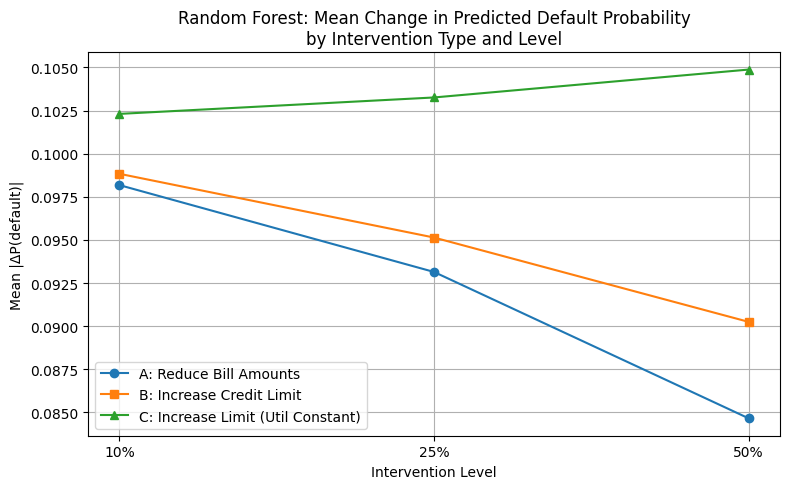

In [51]:
# Summary Comparison Plot
# Line chart of mean |ΔP| vs intervention level for all three interventions

levels = [0.10, 0.25, 0.50]
labels = ['10%', '25%', '50%']

mean_A = [np.abs(results_A[p]).mean() for p in levels]
mean_B = [np.abs(results_B[p]).mean() for p in levels]
mean_C = [np.abs(results_C[p]).mean() for p in levels]

plt.figure(figsize=(8, 5))
plt.plot(labels, mean_A, marker='o', label='A: Reduce Bill Amounts')
plt.plot(labels, mean_B, marker='s', label='B: Increase Credit Limit')
plt.plot(labels, mean_C, marker='^', 
         label='C: Increase Limit (Util Constant)')
plt.xlabel('Intervention Level')
plt.ylabel('Mean |ΔP(default)|')
plt.title('Random Forest: Mean Change in Predicted Default Probability\n'
          'by Intervention Type and Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('MLP_counterfactual_comparison.png', dpi=150)
plt.show()

In [53]:
# Client Segmentation Analysis - PyTorch version

with torch.no_grad():
    baseline_probs = torch.sigmoid(model(x_test)).cpu().numpy().flatten()

high_risk_mask = baseline_probs > 0.5
low_risk_mask  = baseline_probs < 0.4

print(f"High-risk clients (P > 0.5): {high_risk_mask.sum()}")
print(f"Low-risk clients  (P < 0.4): {low_risk_mask.sum()}")

for mask, group_label in [(high_risk_mask, 'High-Risk'),
                          (low_risk_mask,  'Low-Risk')]:
    X_group = x_test[mask]  # tensor indexing
    
    if X_group.shape[0] == 0:
        print(f"\n{group_label} group is empty, skipping.")
        continue
    
    print(f"\n=== {group_label} Group (n={X_group.shape[0]}) ===")
    
    # Intervention A: Reduce bills by 25%
    def int_A_seg(X):
        X_mod = X.clone()
        # Reduce bill amounts
        X_mod[:, bill_idx] = X_mod[:, bill_idx] * 0.75
        # Recompute utilization ratios
        limit = X_mod[:, limit_idx].unsqueeze(1)
        limit_safe = torch.where(limit == 0, torch.nan, limit)
        X_mod[:, util_idx] = X_mod[:, bill_idx] / limit_safe
        # Compute UTIL_avg
        X_mod[:, util_avg_idx] = torch.nanmean(X_mod[:, util_idx], dim=1)
        # Clip
        cols_to_clip = bill_idx + util_idx + [util_avg_idx]
        for col in cols_to_clip:
            X_mod[:, col] = torch.clamp(X_mod[:, col],
                                        min=x_train[:, col].min(),
                                        max=x_train[:, col].max())
        return X_mod

    # Intervention B: Increase limit by 25%
    def int_B_seg(X):
        X_mod = X.clone()
        # Increase limit
        X_mod[:, limit_idx] = X_mod[:, limit_idx] * 1.25
        # Recompute utilization ratios
        limit = X_mod[:, limit_idx].unsqueeze(1)
        limit_safe = torch.where(limit == 0, torch.nan, limit)
        X_mod[:, util_idx] = X_mod[:, bill_idx] / limit_safe
        # Compute UTIL_avg
        X_mod[:, util_avg_idx] = torch.nanmean(X_mod[:, util_idx], dim=1)
        # Clip
        cols_to_clip = [limit_idx] + util_idx + [util_avg_idx]
        for col in cols_to_clip:
            X_mod[:, col] = torch.clamp(X_mod[:, col],
                                        min=x_train[:, col].min(),
                                        max=x_train[:, col].max())
        return X_mod
    
    run_intervention(model, X_group, int_A_seg,
                     f"{group_label} - Intervention A (25% bill reduction)")
    
    run_intervention(model, X_group, int_B_seg,
                     f"{group_label} - Intervention B (25% limit increase)")

High-risk clients (P > 0.5): 848
Low-risk clients  (P < 0.4): 1562

=== High-Risk Group (n=848) ===

--- High-Risk - Intervention A (25% bill reduction) ---
Mean ΔP(default)       : -0.076937
Mean |ΔP(default)|     : 0.097627
Clients with reduction : 421 / 848

--- High-Risk - Intervention B (25% limit increase) ---
Mean ΔP(default)       : -0.079144
Mean |ΔP(default)|     : 0.096339
Clients with reduction : 419 / 848

=== Low-Risk Group (n=1562) ===

--- Low-Risk - Intervention A (25% bill reduction) ---
Mean ΔP(default)       : 0.011748
Mean |ΔP(default)|     : 0.086239
Clients with reduction : 559 / 1562

--- Low-Risk - Intervention B (25% limit increase) ---
Mean ΔP(default)       : 0.019000
Mean |ΔP(default)|     : 0.089814
Clients with reduction : 471 / 1562
